# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib

# LOAD DATASET

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# PROBLEM DEFINITION

In [3]:
# Goal: Predict loan approval (Loan Status)

target_column = 'loan_status'   # adjust if needed
print(df[target_column].value_counts())

0    25473
1     7108
Name: loan_status, dtype: int64


# DATA CLEANING

In [4]:
# Missing values
print(df.isnull().sum())

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


# EDA (EXPLORATORY DATA ANALYSIS)

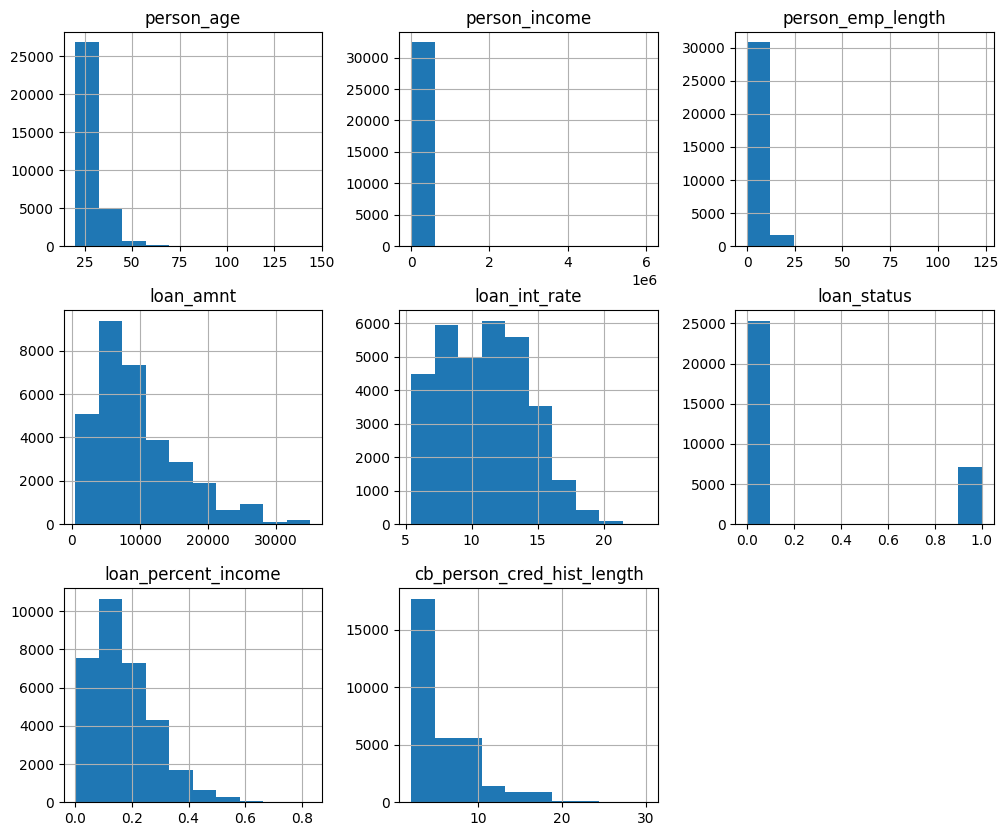

C:\Users\dell\AppData\Local\Temp\ipykernel_9776\1000041722.py:7: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


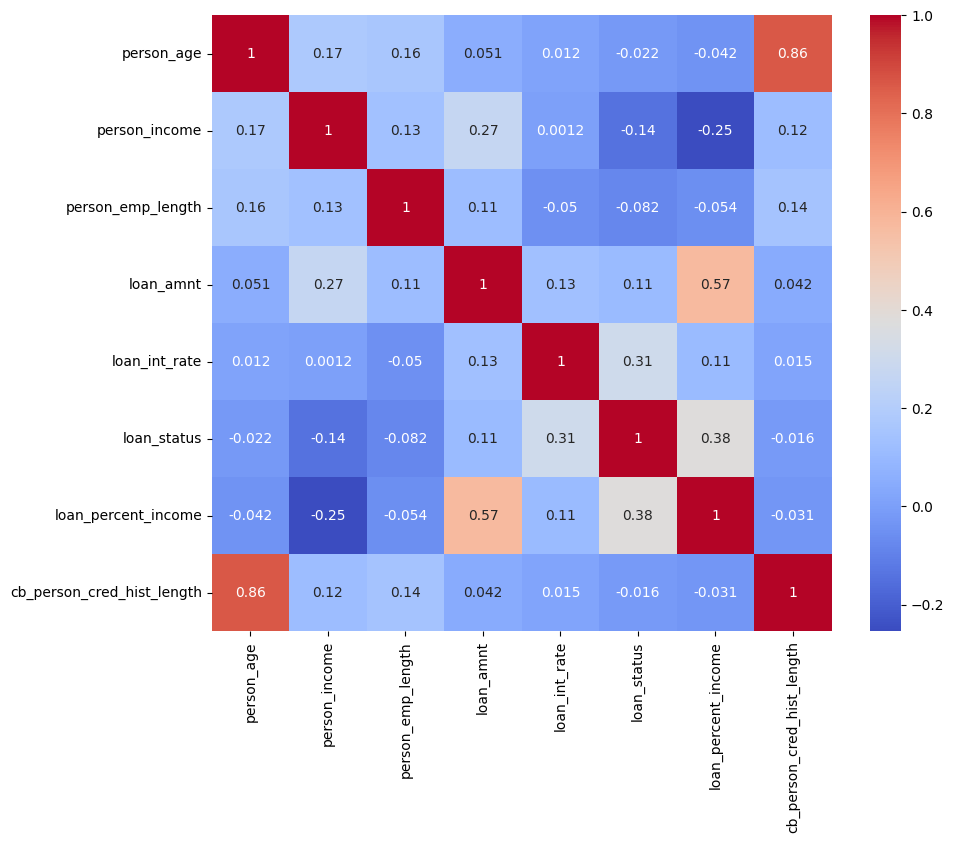

In [5]:
# Distribution
df.hist(figsize=(12,10))
plt.show()

# Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# CATEGORICAL ENCODING

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# FEATURE & TARGET SPLIT

In [7]:
X = df.drop(target_column, axis=1)
y = df[target_column]

# HANDLE IMBALANCED DATA

In [8]:
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

# TRAIN TEST SPLIT

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# FEATURE SCALING

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL TRAINING (MULTIPLE MODELS)

In [11]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc}")

Logistic Regression: 0.7756410256410257
Random Forest: 0.9243589743589744
XGBoost: 0.9502958579881656


# BEST MODEL SELECTION

In [12]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: XGBoost


# HYPERPARAMETER TUNING

In [13]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


# MODEL EVALUATION

Accuracy: 0.868836291913215
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      5065
           1       0.91      0.82      0.86      5075

    accuracy                           0.87     10140
   macro avg       0.87      0.87      0.87     10140
weighted avg       0.87      0.87      0.87     10140



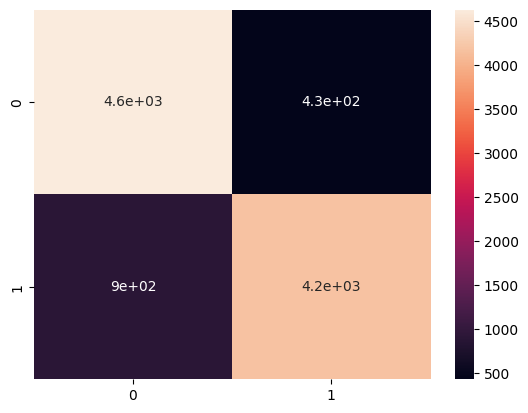

In [14]:
preds = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

sns.heatmap(confusion_matrix(y_test, preds), annot=True)
plt.show()

# SAVE MODEL 

In [15]:
joblib.dump(best_model, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# FEATURE IMPORTANCE

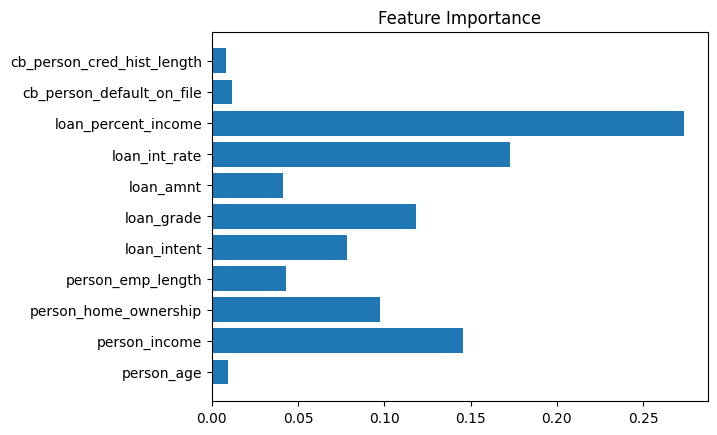

In [16]:
importances = best_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

# STREAMLIT APP

In [37]:
import os, subprocess, time, webbrowser

app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import os, hashlib, jwt, datetime, joblib
import plotly.express as px

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# SAFE XGBOOST
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False

# SAFE SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False

# ================= SESSION INIT =================
def init_session():
    defaults = {
        "token": None,
        "model": None,
        "features": None,
        "target": None,
        "data": None,
        "scaler": None,
        "encoders": None
    }
    for k,v in defaults.items():
        if k not in st.session_state:
            st.session_state[k] = v

init_session()

# ================= CONFIG =================
SECRET_KEY = "loan_app_secret"
MODEL_FILE = "model.pkl"
USER_FILE = "users.csv"

# ================= AUTH =================
def hash_pass(p):
    return hashlib.sha256(p.encode()).hexdigest()

def load_users():
    if not os.path.exists(USER_FILE):
        pd.DataFrame(columns=["username","password","role"]).to_csv(USER_FILE,index=False)
    return pd.read_csv(USER_FILE)

def save_users(df):
    df.to_csv(USER_FILE,index=False)

def create_token(user, role):
    return jwt.encode({
        "user": user,
        "role": role,
        "exp": datetime.datetime.utcnow() + datetime.timedelta(hours=5)
    }, SECRET_KEY, algorithm="HS256")

def decode_token(token):
    try:
        return jwt.decode(token, SECRET_KEY, algorithms=["HS256"])
    except:
        return None

# ================= PREPROCESS =================
def preprocess(X):
    X = X.copy()
    encoders = {}

    for col in X.columns:
        if X[col].dtype == "object":
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            encoders[col] = le
        else:
            X[col] = X[col].fillna(X[col].mean())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, scaler, encoders

# ================= UI =================
st.set_page_config(layout="wide")
st.title("💰 Ultimate Loan Predictor (Final Fixed)")

menu = st.sidebar.selectbox("Menu",["Login","Register"])

# ================= LOGIN =================
if st.session_state["token"] is None:

    if menu == "Register":
        st.subheader("Register")
        u = st.text_input("Username")
        p = st.text_input("Password", type="password")
        r = st.selectbox("Role",["user","admin"])

        if st.button("Register"):
            df = load_users()
            if u in df.username.values:
                st.warning("User exists")
            else:
                df.loc[len(df)] = [u, hash_pass(p), r]
                save_users(df)
                st.success("Registered")

    elif menu == "Login":
        st.subheader("Login")
        u = st.text_input("Username")
        p = st.text_input("Password", type="password")

        if st.button("Login"):
            df = load_users()
            res = df[(df.username==u)&(df.password==hash_pass(p))]
            if not res.empty:
                st.session_state["token"] = create_token(u, res.iloc[0]["role"])
                st.success("Login success")
                st.rerun()
            else:
                st.error("Invalid credentials")

# ================= MAIN =================
else:
    data = decode_token(st.session_state["token"])

    if data is None:
        st.session_state["token"] = None
        st.error("Session expired")
        st.stop()

    role = data["role"]
    st.sidebar.write(f"👤 {data['user']} ({role})")

    if st.sidebar.button("Logout"):
        st.session_state["token"] = None
        st.rerun()

    page = st.sidebar.selectbox("Page",
        ["Upload Dataset","Train Model","Dashboard","Predict","Explain","Admin Panel"] if role=="admin"
        else ["Upload Dataset","Predict"]
    )

# ================= UPLOAD =================
    if page == "Upload Dataset":
        file = st.file_uploader("Upload CSV")

        if file:
            df = pd.read_csv(file)
            st.session_state["data"] = df
            st.dataframe(df.head())

            target = st.selectbox("Target Column", df.columns)

            st.session_state["target"] = target
            st.session_state["features"] = df.drop(target,axis=1).columns

# ================= TRAIN =================
    elif page == "Train Model":
        df = st.session_state["data"]

        if df is None:
            st.warning("Upload dataset first")
        else:
            target = st.session_state["target"]
            X = df.drop(target, axis=1)
            y = df[target]

            X_processed, scaler, encoders = preprocess(X)

            st.session_state["scaler"] = scaler
            st.session_state["encoders"] = encoders

            X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2)

            models = {
                "RandomForest": RandomForestClassifier(),
                "Logistic": LogisticRegression(max_iter=500)
            }

            if XGB_AVAILABLE:
                models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
                st.success("XGBoost Loaded")
            else:
                st.warning("XGBoost not installed")

            best_acc = 0
            best_model = None

            for name, model in models.items():
                model.fit(X_train, y_train)
                pred = model.predict(X_test)
                acc = accuracy_score(y_test, pred)
                st.write(f"{name}: {acc:.3f}")

                if acc > best_acc:
                    best_acc = acc
                    best_model = model

            joblib.dump(best_model, MODEL_FILE)
            st.session_state["model"] = best_model

            st.success(f"Best Accuracy: {best_acc:.3f}")

            cm = confusion_matrix(y_test, best_model.predict(X_test))
            st.write("Confusion Matrix")
            st.write(cm)

# ================= DASHBOARD =================
    elif page == "Dashboard":
        df = st.session_state["data"]
        if df is not None:
            col = st.selectbox("Column", df.columns)
            st.plotly_chart(px.histogram(df, x=col))
        else:
            st.warning("Upload dataset first")

# ================= PREDICT =================
    elif page == "Predict":
        if not os.path.exists(MODEL_FILE):
            st.warning("Train model first")
        else:
            model = joblib.load(MODEL_FILE)

            inputs = []
            for col in st.session_state["features"]:
                inputs.append(st.number_input(col, value=0.0))

            if st.button("Predict"):
                X = np.array([inputs])
                pred = model.predict(X)
                st.success(f"Prediction: {pred[0]}")

                pd.DataFrame([inputs], columns=st.session_state["features"])\
                  .assign(Prediction=pred[0])\
                  .to_csv("prediction.csv", index=False)

                st.download_button("Download Report", open("prediction.csv","rb"), "prediction.csv")

# ================= EXPLAIN =================
    elif page == "Explain":
        st.subheader("🧠 Model Explainability")

        if not os.path.exists(MODEL_FILE):
            st.warning("Train model first")
    
        else:
            model = joblib.load(MODEL_FILE)
            df = st.session_state["data"]

            if df is None:
                st.warning("Upload dataset first")

            else:
                X = df.drop(st.session_state["target"], axis=1)
                X_processed, _, _ = preprocess(X)

                # ================= FEATURE IMPORTANCE =================
                st.subheader("📊 Feature Importance")
    
                try:
                    importance = model.feature_importances_
                    st.bar_chart(pd.DataFrame({
                        "Feature": st.session_state["features"],
                        "Importance": importance
                    }).set_index("Feature"))
                except:
                    st.info("Feature importance not available for this model")

                # ================= SHAP =================
                st.subheader("🔍 SHAP Explainability")

                try:
                    import shap
                    explainer = shap.Explainer(model, X_processed)
                    shap_values = explainer(X_processed[:50])

                    shap.plots.beeswarm(shap_values, show=False)
                    st.pyplot()

                except:
                    st.warning("⚠️ SHAP not installed or failed → showing fallback")

                    # fallback visualization
                    st.write("Showing correlation heatmap instead")
                    st.dataframe(df.corr())

# ================= ADMIN =================
    elif page == "Admin Panel":
        df = load_users()
        st.dataframe(df)

        user_del = st.selectbox("Delete User", df.username)

        if st.button("Delete"):
            df = df[df.username != user_del]
            save_users(df)
            st.success("Deleted")
'''

with open("app.py","w",encoding="utf-8") as f:
    f.write(app_code)

print("✅ app.py created")

# RUN STREAMLIT CORRECTLY
process = subprocess.Popen(["streamlit","run","app.py"])

time.sleep(5)
webbrowser.open("http://localhost:8501")

print("🚀 App Running Successfully")

✅ app.py created
🚀 App Running Successfully
